In [1]:
import pandas as pd

resume_df = pd.read_csv("resume.csv")
job_df = pd.read_csv("jobs.csv")

print(resume_df.columns)
print(job_df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Index(['country', 'country_code', 'date_added', 'has_expired', 'job_board',
       'job_description', 'job_title', 'job_type', 'location', 'organization',
       'page_url', 'salary', 'sector', 'uniq_id'],
      dtype='object')


In [2]:
selected_job = job_df[job_df["job_title"].str.contains("Data Scientist", case=False, na=False)]

job_text = selected_job["job_description"].values[0]

In [3]:
print(job_text[:1000])

Senior Data Scientist - Python, R, Julia Job in San Francisco 94108, California US CyberCoders Search. Apply. Done. Learn more about CyberCoders Senior Data Scientist Apply San Francisco, CA Full-Time $120,000 - $175,000 Job Details If you are a Senior Data Scientist with experience at a product-driven technology company, please read on!Job Title: Senior Data ScientistLocation: San Francisco, CAThe Salary: $120k- 175kThe Company: We have created web and mobile tools to help users in areas such as cognitive training, sleep, and mindfulness. These tools include games for improving memory, attention, flexibility, speed of processing, and problem solving. We are the leading brain training program with more than 50 million users. Come join our team of brainiacs and help build cognitive features for members all over the world!!Top Reasons to Work with Us- Weekly all-hands lunches for anyone to present their work- High percentage of promotion from within -Regular team bonding events- Always c

Clean Resume Text

In [4]:
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kruth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kruth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Clean Resume Dataset

In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kruth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kruth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kruth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
resume_df["Cleaned_Resume"] = resume_df["Resume_str"].apply(clean_text)
job_clean = clean_text(job_text)

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

TF-IDF Vectorization

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = resume_df["Cleaned_Resume"].tolist()
texts.append(job_clean)

tfidf = TfidfVectorizer()
vectors = tfidf.fit_transform(texts)

Similarity Score

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

resume_vectors = vectors[:-1]
job_vector = vectors[-1]

scores = cosine_similarity(resume_vectors, job_vector)

resume_df["Score"] = scores

Rank Candidates

In [10]:
resume_df = resume_df.sort_values(by="Score", ascending=False)
resume_df.reset_index(drop=True, inplace=True)

resume_df["Rank"] = range(1, len(resume_df)+1)

Top Candidates

In [11]:
print(resume_df[["Rank", "Category", "Score"]].head(10))

   Rank       Category     Score
0     1             HR  0.115156
1     2             HR  0.112870
2     3     HEALTHCARE  0.094963
3     4             HR  0.093840
4     5             HR  0.093219
5     6     CONSULTANT  0.092152
6     7        BANKING  0.091995
7     8    ENGINEERING  0.088702
8     9  DIGITAL-MEDIA  0.088054
9    10    AGRICULTURE  0.086860


In [12]:
skills = [
    "python", "machine learning", "sql",
    "pandas", "data analysis", "r",
    "statistics", "excel", "deep learning"
]

Finding missing skills

In [13]:
def missing_skills(text):
    text = text.lower()
    missing = []
    
    for skill in skills:
        if skill not in text:
            missing.append(skill)
    
    return ", ".join(missing)

resume_df["Missing_Skills"] = resume_df["Resume_str"].apply(missing_skills)

Show Final Recruiter Output

In [14]:
print(resume_df[["Rank","Category","Score","Missing_Skills"]].head(10))

   Rank       Category     Score  \
0     1             HR  0.115156   
1     2             HR  0.112870   
2     3     HEALTHCARE  0.094963   
3     4             HR  0.093840   
4     5             HR  0.093219   
5     6     CONSULTANT  0.092152   
6     7        BANKING  0.091995   
7     8    ENGINEERING  0.088702   
8     9  DIGITAL-MEDIA  0.088054   
9    10    AGRICULTURE  0.086860   

                                      Missing_Skills  
0  python, machine learning, sql, pandas, data an...  
1  python, machine learning, sql, pandas, data an...  
2  python, machine learning, sql, pandas, data an...  
3  python, machine learning, pandas, data analysi...  
4  python, machine learning, sql, pandas, data an...  
5           pandas, statistics, excel, deep learning  
6  python, machine learning, sql, pandas, deep le...  
7  python, machine learning, sql, pandas, statist...  
8  python, machine learning, sql, pandas, data an...  
9  machine learning, data analysis, statistics, e... 

In [15]:
selected_job = job_df[job_df["job_title"].str.contains("Python|Machine Learning|Data Scientist", case=False, na=False)]

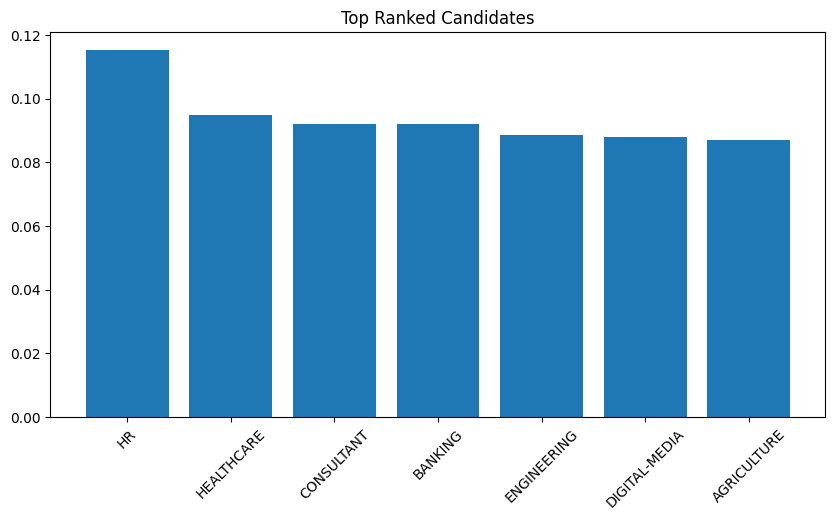

In [16]:
import matplotlib.pyplot as plt

top10 = resume_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Category"], top10["Score"])
plt.xticks(rotation=45)
plt.title("Top Ranked Candidates")
plt.show()


Missing Skills Detection

In [17]:
skills = [
    "python", "sql", "machine learning",
    "pandas", "statistics", "excel",
    "communication", "deep learning", "r"
]

def find_missing(text):
    text = text.lower()
    missing = []
    
    for skill in skills:
        if skill not in text:
            missing.append(skill)
    
    return ", ".join(missing)

resume_df["Missing_Skills"] = resume_df["Resume_str"].apply(find_missing)

Final Top Candidates

In [18]:
print(resume_df[["Rank","Category","Score","Missing_Skills"]].head(10))

   Rank       Category     Score  \
0     1             HR  0.115156   
1     2             HR  0.112870   
2     3     HEALTHCARE  0.094963   
3     4             HR  0.093840   
4     5             HR  0.093219   
5     6     CONSULTANT  0.092152   
6     7        BANKING  0.091995   
7     8    ENGINEERING  0.088702   
8     9  DIGITAL-MEDIA  0.088054   
9    10    AGRICULTURE  0.086860   

                                      Missing_Skills  
0  python, sql, machine learning, pandas, statist...  
1  python, sql, machine learning, pandas, statist...  
2  python, sql, machine learning, pandas, excel, ...  
3  python, machine learning, pandas, statistics, ...  
4  python, sql, machine learning, pandas, deep le...  
5  pandas, statistics, excel, communication, deep...  
6  python, sql, machine learning, pandas, deep le...  
7  python, sql, machine learning, pandas, statist...  
8  python, sql, machine learning, pandas, statist...  
9  machine learning, statistics, excel, communica... 

Best Candidate Summary

In [19]:
best = resume_df.iloc[0]

print("Best Candidate Rank:", best["Rank"])
print("Category:", best["Category"])
print("Score:", best["Score"])
print("Missing Skills:", best["Missing_Skills"])

Best Candidate Rank: 1
Category: HR
Score: 0.11515634643983023
Missing Skills: python, sql, machine learning, pandas, statistics, communication, deep learning


In [20]:
resume_df.to_csv("final_ranked_candidates.csv", index=False)

In [21]:
selected_job = job_df[job_df["job_title"].str.contains("Python|Machine Learning|Data Scientist", case=False, na=False)]
job_text = selected_job["job_description"].values[0]

In [22]:
job_clean = clean_text(job_text)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = resume_df["Cleaned_Resume"].tolist()
texts.append(job_clean)

tfidf = TfidfVectorizer()
vectors = tfidf.fit_transform(texts)

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

resume_vectors = vectors[:-1]
job_vector = vectors[-1]

scores = cosine_similarity(resume_vectors, job_vector)

resume_df["Score"] = scores

In [25]:
resume_df = resume_df.sort_values(by="Score", ascending=False)
resume_df.reset_index(drop=True, inplace=True)
resume_df["Rank"] = range(1, len(resume_df)+1)

In [26]:
print(resume_df[["Rank","Category","Score"]].head(10))

   Rank                Category     Score
0     1             ENGINEERING  0.199471
1     2             AGRICULTURE  0.169367
2     3  INFORMATION-TECHNOLOGY  0.161916
3     4    BUSINESS-DEVELOPMENT  0.160961
4     5              CONSULTANT  0.159378
5     6              CONSULTANT  0.151204
6     7           DIGITAL-MEDIA  0.150534
7     8              AUTOMOBILE  0.148249
8     9           DIGITAL-MEDIA  0.148225
9    10                   SALES  0.145523


In [28]:
resume_df.head(100).to_csv("final_ranked_candidates.csv", index=False)

# Resume / Candidate Screening System using Machine Learning

## Objective
To develop an automated resume screening system that compares candidate resumes with a selected job role and ranks candidates based on relevance.

## Datasets Used
- `resume.csv` – Candidate resumes with categories
- `jobs.csv` – Job titles and job descriptions

## Libraries Used
- Python
- Pandas
- NLTK
- Scikit-learn
- Matplotlib

## Workflow Implemented

### 1. Data Loading
Loaded both datasets using Pandas DataFrames.

### 2. Job Role Filtering
Selected technical roles such as:
- Python Developer
- Machine Learning
- Data Scientist

using keyword filtering on `job_title`.

### 3. Text Cleaning
Created a custom `clean_text()` function to:
- convert text to lowercase
- remove special characters
- remove stopwords
- split words and rejoin clean text

Applied cleaning to:
- Resume text (`Resume_str`)
- Selected job description

### 4. Feature Extraction
Used TF-IDF Vectorizer to convert resume text and job description into numerical vectors.

### 5. Similarity Matching
Used Cosine Similarity to compare each resume with the selected job description.

### 6. Candidate Ranking
Sorted candidates by similarity score in descending order and assigned ranks.

### 7. Missing Skills Detection
Checked resumes for important skills such as:
- Python
- SQL
- Machine Learning
- Pandas
- Statistics
- Communication

### 8. Visualization
Generated bar chart for top ranked candidates and their scores.

### 9. Export Results
Saved final ranked output into:

`final_ranked_candidates.csv`

## Result
The system successfully ranked resumes according to job relevance and identified missing skills.

## Conclusion
This project shows how NLP and Machine Learning can automate recruitment screening and improve hiring efficiency.